In [5]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"

for p in DATA_INTERIM.iterdir():
    print(p.name)

sevilla_voxcity_metadata.json
sevilla_trees_voxcity.gpkg
sevilla_eubucco_buildings.gpkg
.gitkeep
sevilla_voxcity_initial.nc
sevilla_buildings_voxcity.gpkg


In [6]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
DATA_INTERIM = PROJECT_ROOT / "data" / "interim"

for p in sorted(DATA_INTERIM.iterdir()):
    print(p.name)

.gitkeep
sevilla_buildings_voxcity.gpkg
sevilla_eubucco_buildings.gpkg
sevilla_trees_voxcity.gpkg
sevilla_voxcity_initial.nc
sevilla_voxcity_metadata.json


In [7]:
import xarray as xr
import geopandas as gpd

# baseline height grid
ds_baseline = xr.open_dataset(
    DATA_INTERIM / "sevilla_voxcity_initial.nc"
)

old = ds_baseline["building_height"].values

# enriched EUBUCCO buildings
eubucco_clean = gpd.read_file(
    DATA_INTERIM / "sevilla_eubucco_buildings.gpkg"
)

print(old.shape)
print(len(eubucco_clean))

(412, 412)
4298


In [9]:
import json
import xarray as xr

ds_baseline = xr.open_dataset(
    DATA_INTERIM / "sevilla_voxcity_initial.nc"
)

rectangle_vertices = json.loads(
    ds_baseline.attrs["rectangle_vertices"]
)

print(rectangle_vertices)

[[-5.96850346486674, 37.38294295915931], [-5.96850346486674, 37.40151128213675], [-5.9452312992316525, 37.40151128213675], [-5.9452312992316525, 37.38294295915931]]


INFO | voxcity.voxcity.generator.api | Auto-selecting data sources for: building_source, land_cover_source, canopy_height_source, dem_source, building_complementary_source


Loading formatted geocoded file...


INFO | voxcity.voxcity.generator.api | Detected country for ROI center (-5.9569, 37.3922): Spain
INFO | voxcity.voxcity.generator.api | Selected data sources:
INFO | voxcity.voxcity.generator.api | - Buildings(base)=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - Buildings(comp)=Microsoft Building Footprints | https://github.com/microsoft/GlobalMLBuildingFootprints
INFO | voxcity.voxcity.generator.api | - LandCover=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - Canopy=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - DEM=Flat
INFO | voxcity.voxcity.generator.api | - ComplementHeight=10
INFO | voxcity.voxcity.utils.cache | Using cached load_gdf_from_openstreetmap result (e6de0f4d9bc39caafaae780cb001e825.pkl)
INFO | voxcity.voxcity.utils.cache | Using cached load_land_cover_gdf_from_osm result (d6fd8d8d3e27ab94ddbc30de899a9b54.pkl)
INFO | voxcity.voxcity.utils.cache | Using


  • Land Cover:  OpenStreetMap
  • Building:    OpenStreetMap
  • Canopy:      OpenStreetMap
  • DEM:         Flat
------------------------------------------------------------
Downloading... (this may take a moment)
  ✓ Dem complete (1/4)
  ✓ Building complete (2/4)


INFO | voxcity.voxcity.downloader.osm | Overpass attempt failed: server error (HTTP 504) from https://overpass-api.de/api/interpreter


  ✓ Land Cover complete (3/4)


INFO | voxcity.voxcity.downloader.osm | Overpass attempt failed: timeout after 60s from https://overpass.kumi.systems/api/interpreter
INFO | voxcity.voxcity.downloader.osm | Overpass endpoint unreachable, marking dead for this call: https://overpass.openstreetmap.ru/api/interpreter (HTTPSConnectionPool(host='overpass.openstreetmap.ru', port=443): Max retries exceeded with url: /api/interpreter?data=%0A++++++++%5Bout%3Ajson%5D%3B%0A++++++++%28%0A++++++++++node%5B%22natural%22%3D%22tree%22%5D%2837.38294295915931%2C-5.96850346486674%2C37.40151128213675%2C-5.9452312992316525%29%3B%0A++++++++++way%5B%22natural%22%3D%22wood%22%5D%2837.38294295915931%2C-5.96850346486674%2C37.40151128213675%2C-5.9452312992316525%29%3B%0A++++++++++way%5B%22landuse%22%3D%22forest%22%5D%2837.38294295915931%2C-5.96850346486674%2C37.40151128213675%2C-5.9452312992316525%29%3B%0A++++++++++way%5B%22natural%22%3D%22tree_row%22%5D%2837.38294295915931%2C-5.96850346486674%2C37.40151128213675%2C-5.9452312992316525%29%3B%0A

  Downloaded 716 individual trees and 6 tree polygons from OSM
  Downloaded 722 trees from OSM
  Created canopy grids: (412, 412)
  ✓ Canopy complete (4/4)
------------------------------------------------------------
All downloads complete!



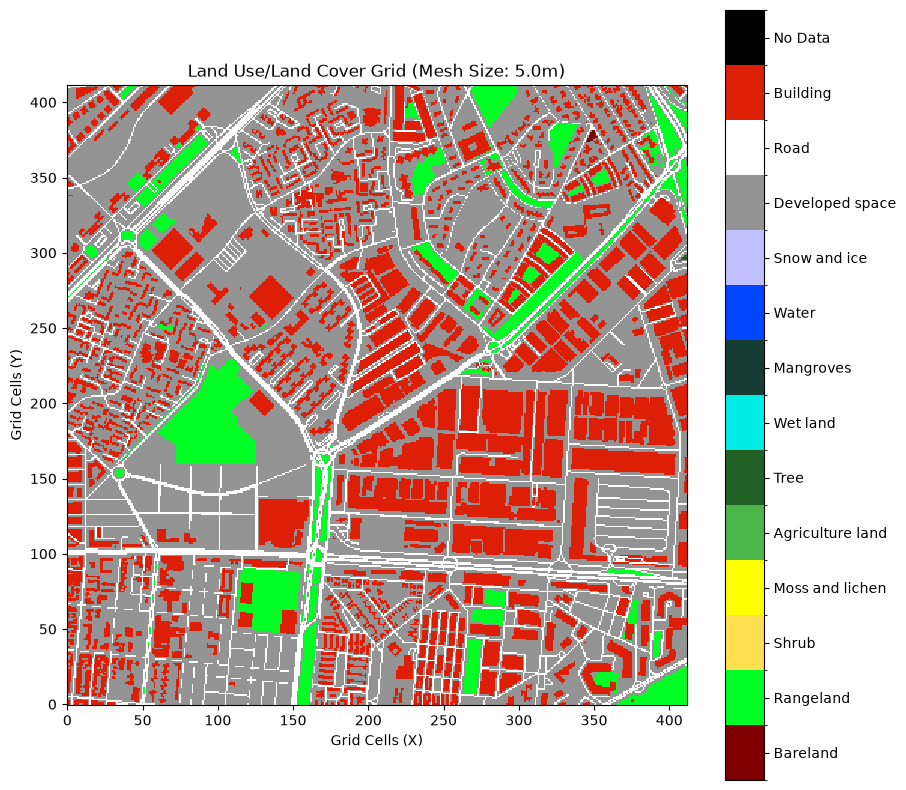

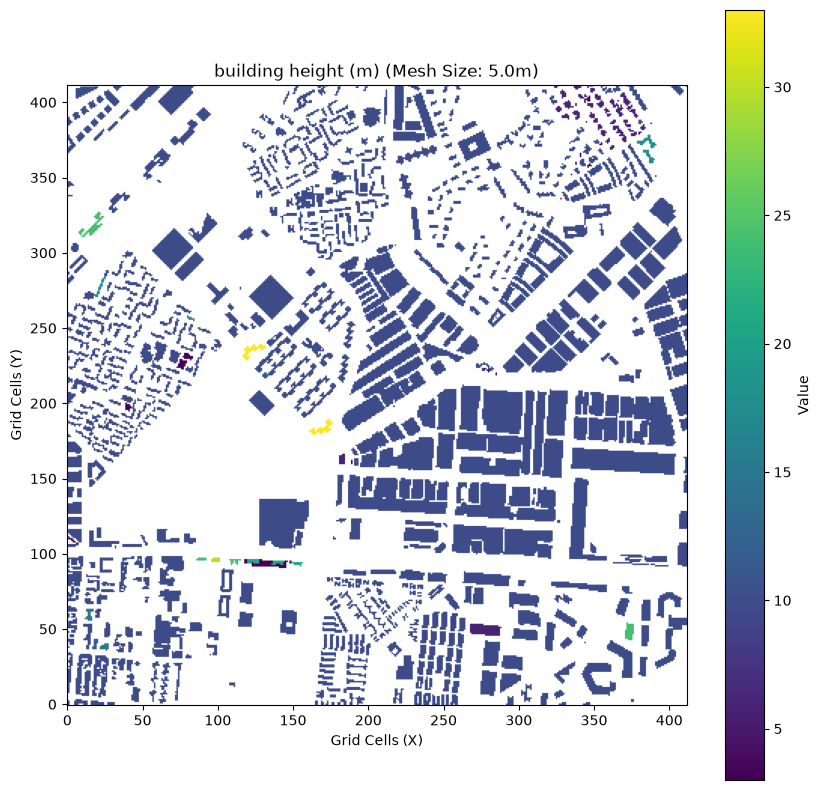

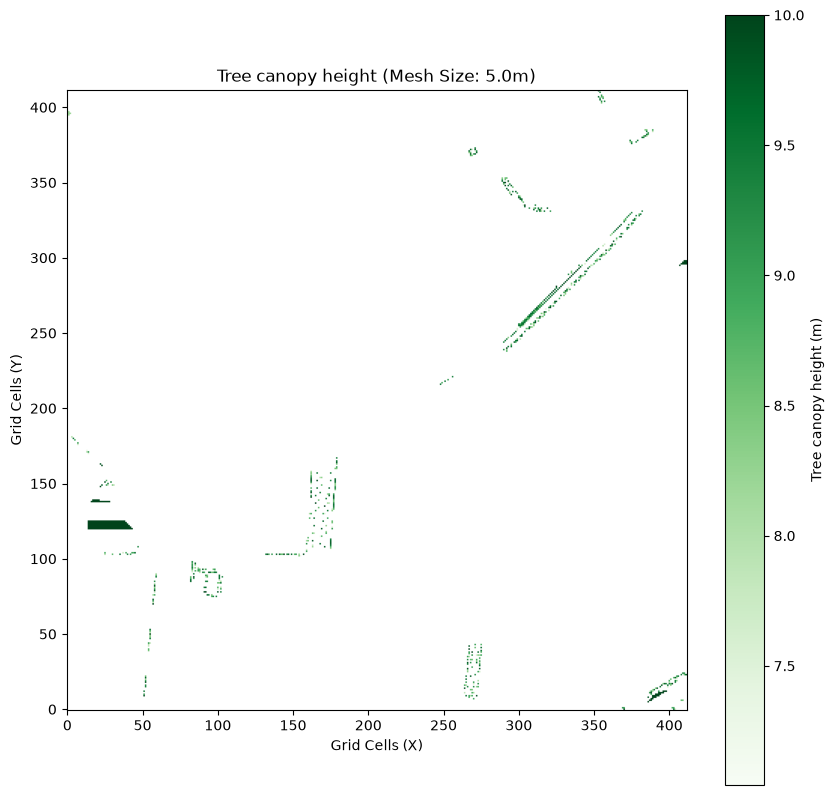

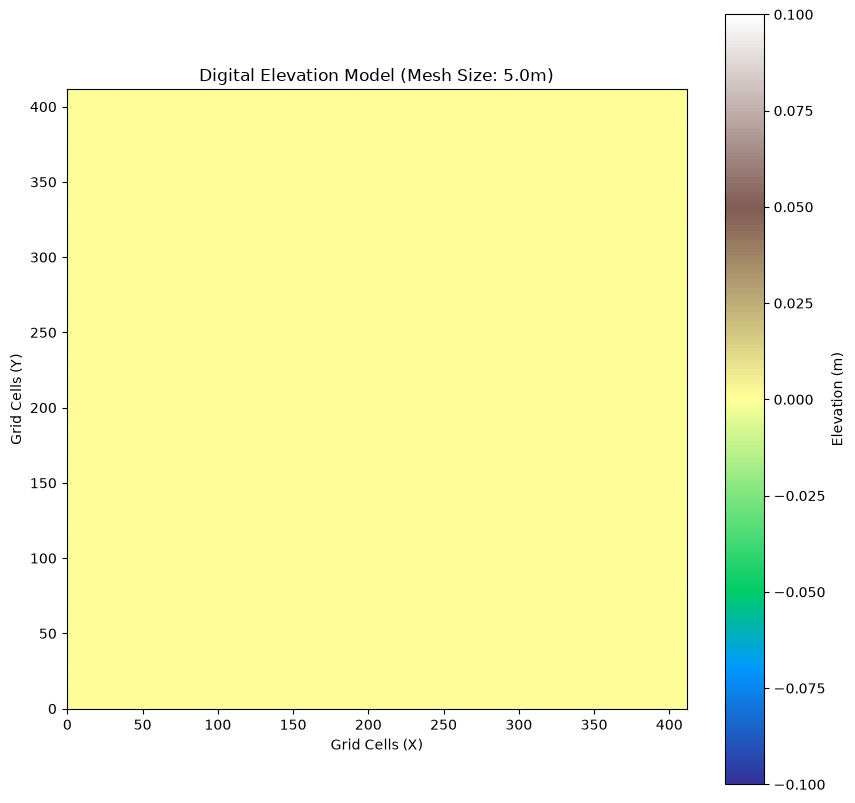

INFO | voxcity.voxcity.generator.voxelizer | Generating 3D voxel data
INFO | voxcity.voxcity.generator.voxelizer | 
Voxel Grid Semantic Codes:
  -3 : Building volume
  -2 : Tree canopy (vegetation)
  -1 : Ground/Subsurface
  >=1: Land cover class at ground surface (see Land Cover Classes)

INFO | voxcity.voxcity.generator.voxelizer | 
VoxCity Standard Land Cover Classes (1-based indices, used in voxel grids):
--------------------------------------------------
   1: Bareland           - Bare soil, rocks, desert
   2: Rangeland          - Grassland, pasture
   3: Shrub              - Shrubland, bushes
   4: Agriculture land   - Cropland, farmland
   5: Tree               - Forest, tree cover
   6: Moss and lichen    - Moss, lichen cover
   7: Wet land           - Wetland, marsh
   8: Mangrove           - Mangrove forest
   9: Water              - Water bodies
  10: Snow and ice       - Snow, ice, glaciers
  11: Developed space    - Urban areas, parking
  12: Road               - Roads, p

VoxCity results saved to output/voxcity.h5


In [10]:
from voxcity.generator import get_voxcity, update_voxcity, save_voxcity

voxcity_model = get_voxcity(
    rectangle_vertices,
    meshsize=5
)

In [11]:
voxcity_eubucco = update_voxcity(
    voxcity_model,
    building_gdf=eubucco_clean,
    inplace=False
)

INFO | voxcity.voxcity.geoprocessor.raster.buildings | 0 of the total 0 building footprint from the base data source did not have height data.
INFO | voxcity.voxcity.generator.voxelizer | Generating 3D voxel data
INFO | voxcity.voxcity.generator.voxelizer | 
Voxel Grid Semantic Codes:
  -3 : Building volume
  -2 : Tree canopy (vegetation)
  -1 : Ground/Subsurface
  >=1: Land cover class at ground surface (see Land Cover Classes)

INFO | voxcity.voxcity.generator.voxelizer | 
VoxCity Standard Land Cover Classes (1-based indices, used in voxel grids):
--------------------------------------------------
   1: Bareland           - Bare soil, rocks, desert
   2: Rangeland          - Grassland, pasture
   3: Shrub              - Shrubland, bushes
   4: Agriculture land   - Cropland, farmland
   5: Tree               - Forest, tree cover
   6: Moss and lichen    - Moss, lichen cover
   7: Wet land           - Wetland, marsh
   8: Mangrove           - Mangrove forest
   9: Water              - 

In [12]:
save_voxcity(
    DATA_INTERIM / "sevilla_voxcity_eubucco.pkl",
    voxcity_eubucco
)

INFO | voxcity.voxcity.io | Voxcity data saved to /Users/modjrin1/Library/CloudStorage/OneDrive-AaltoUniversity/paper 4 - mobility spain/heat-conditioned-accessibility/data/interim/sevilla_voxcity_eubucco.pkl


In [13]:
print(
    (DATA_INTERIM / "sevilla_voxcity_eubucco.pkl").exists()
)

True


In [14]:
import xarray as xr
import numpy as np
import pandas as pd

ds_baseline = xr.open_dataset(
    DATA_INTERIM / "sevilla_voxcity_initial.nc"
)

old = ds_baseline["building_height"].values
new = voxcity_eubucco.buildings.heights

print("Old positive heights:")
print(pd.Series(old[old > 0]).describe())

print("\nNew positive heights:")
print(pd.Series(new[new > 0]).describe())

mask = (old > 0) | (new > 0)
diff = new - old

print("\nMean absolute difference:", np.abs(diff[mask]).mean())
print("Median absolute difference:", np.median(np.abs(diff[mask])))
print("Maximum absolute difference:", np.abs(diff[mask]).max())

Old positive heights:
count    45453.000000
mean        10.078873
std          1.748261
min          3.000000
25%         10.000000
50%         10.000000
75%         10.000000
max         33.000000
dtype: float64

New positive heights:
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%      NaN
75%      NaN
max      NaN
dtype: float64

Mean absolute difference: 10.078872681671177
Median absolute difference: 10.0
Maximum absolute difference: 33.0


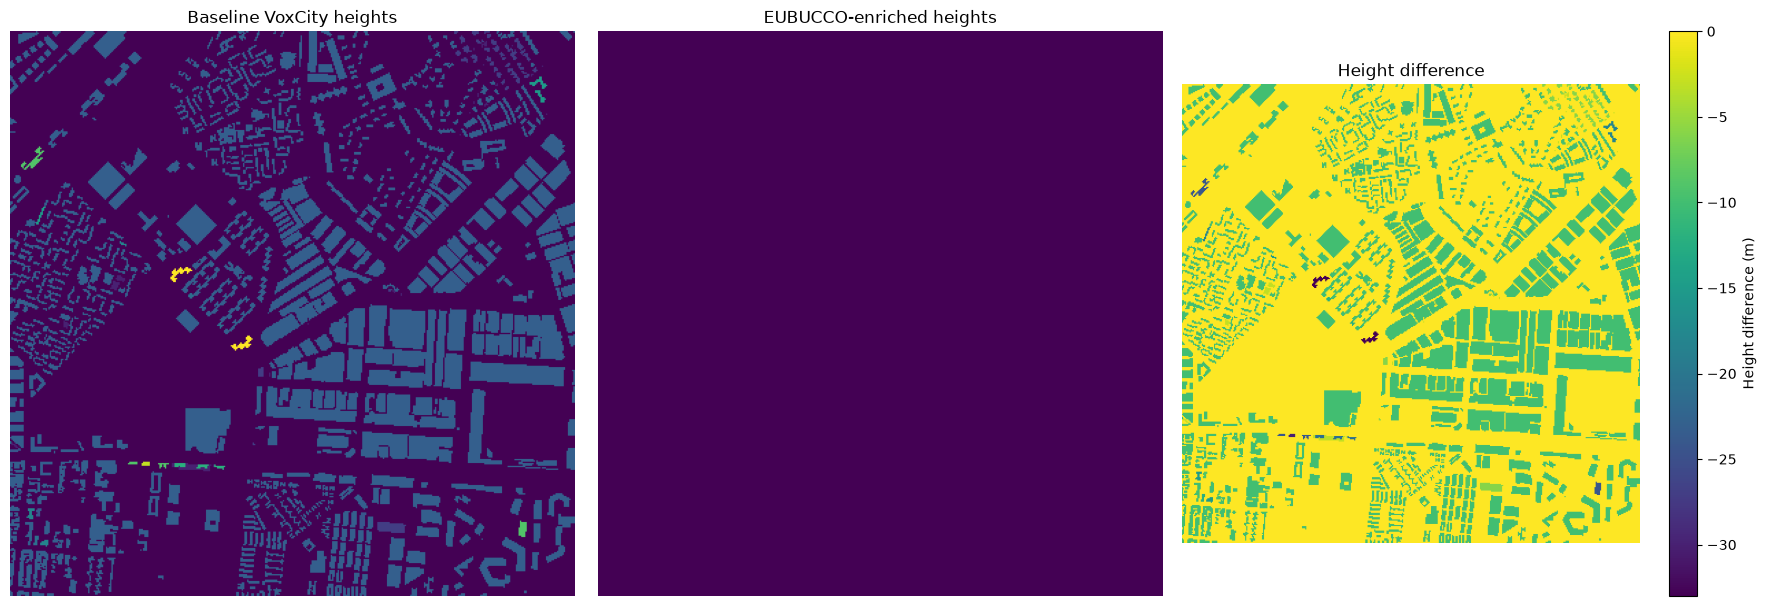

In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(old, origin="lower")
axes[0].set_title("Baseline VoxCity heights")

axes[1].imshow(new, origin="lower")
axes[1].set_title("EUBUCCO-enriched heights")

im = axes[2].imshow(diff, origin="lower")
axes[2].set_title("Height difference")

for ax in axes:
    ax.set_axis_off()

plt.colorbar(im, ax=axes[2], label="Height difference (m)")
plt.tight_layout()
plt.show()

In [17]:
import json

ds_enriched = voxcity_eubucco.to_xarray()

ds_enriched_nc = ds_enriched.copy()
ds_enriched_nc.attrs["rectangle_vertices"] = json.dumps(
    ds_enriched.attrs["rectangle_vertices"].tolist()
)

ds_enriched_nc.to_netcdf(
    DATA_INTERIM / "sevilla_voxcity_eubucco.nc"
)

In [18]:
print(eubucco_clean.crs)
print(eubucco_clean.total_bounds)

EPSG:3035
[2907211.33460592 1737519.42045193 2909434.07779852 1739786.78962518]


In [19]:
eubucco_clean = eubucco_clean.to_crs(4326)

print(eubucco_clean.crs)
print(eubucco_clean.total_bounds)

EPSG:4326
[-5.96848673 37.38294296 -5.94526847 37.40147909]


In [20]:
print(eubucco_clean.columns.tolist())

['id', 'region_id', 'city_id', 'height', 'floors', 'type', 'subtype', 'height_source', 'geometry_source', 'geometry']


In [22]:
if "id" not in eubucco_clean.columns:
    eubucco_clean["id"] = range(
        1,
        len(eubucco_clean) + 1
    )

if "min_height" not in eubucco_clean.columns:
    eubucco_clean["min_height"] = 0.0

In [23]:
print(
    eubucco_clean[
        ["id", "height", "min_height", "geometry"]
    ].head()
)

                   id  height  min_height  \
0  c1d85eb82a034a0d-0     9.2         0.0   
1  142f699fbba94120-0     4.6         0.0   
2  8d6d841c7287435e-1    11.1         0.0   
3  ec5e2e64b67c4eca-3    11.2         0.0   
4  ec5e2e64b67c4eca-2    11.5         0.0   

                                            geometry  
0  MULTIPOLYGON (((-5.95493 37.38329, -5.95485 37...  
1  MULTIPOLYGON (((-5.95768 37.38322, -5.95767 37...  
2  MULTIPOLYGON (((-5.95787 37.38328, -5.9578 37....  
3  MULTIPOLYGON (((-5.95741 37.38343, -5.95741 37...  
4  MULTIPOLYGON (((-5.95758 37.38345, -5.95758 37...  


In [24]:
from voxcity.generator import update_voxcity

voxcity_eubucco = update_voxcity(
    voxcity_model,
    building_gdf=eubucco_clean,
    inplace=False
)

INFO | voxcity.voxcity.geoprocessor.raster.buildings | 0 of the total 4298 building footprint from the base data source did not have height data.
INFO | voxcity.voxcity.generator.voxelizer | Generating 3D voxel data
INFO | voxcity.voxcity.generator.voxelizer | 
Voxel Grid Semantic Codes:
  -3 : Building volume
  -2 : Tree canopy (vegetation)
  -1 : Ground/Subsurface
  >=1: Land cover class at ground surface (see Land Cover Classes)

INFO | voxcity.voxcity.generator.voxelizer | 
VoxCity Standard Land Cover Classes (1-based indices, used in voxel grids):
--------------------------------------------------
   1: Bareland           - Bare soil, rocks, desert
   2: Rangeland          - Grassland, pasture
   3: Shrub              - Shrubland, bushes
   4: Agriculture land   - Cropland, farmland
   5: Tree               - Forest, tree cover
   6: Moss and lichen    - Moss, lichen cover
   7: Wet land           - Wetland, marsh
   8: Mangrove           - Mangrove forest
   9: Water             

In [25]:
new = voxcity_eubucco.buildings.heights

print("Building cells:", (new > 0).sum())
print("Min height:", new[new > 0].min())
print("Mean height:", new[new > 0].mean())
print("Max height:", new[new > 0].max())

Building cells: 47335
Min height: 3.3
Mean height: 14.273548114503011
Max height: 40.4


In [26]:
old = ds_baseline["building_height"].values

mask = (old > 0) | (new > 0)
diff = new - old

print("Old building cells:", (old > 0).sum())
print("New building cells:", (new > 0).sum())
print("Mean absolute difference:", abs(diff[mask]).mean())
print("Median absolute difference:", np.median(abs(diff[mask])))
print("Max absolute difference:", abs(diff[mask]).max())

Old building cells: 45453
New building cells: 47335
Mean absolute difference: 7.052827451122638
Median absolute difference: 5.5
Max absolute difference: 40.4


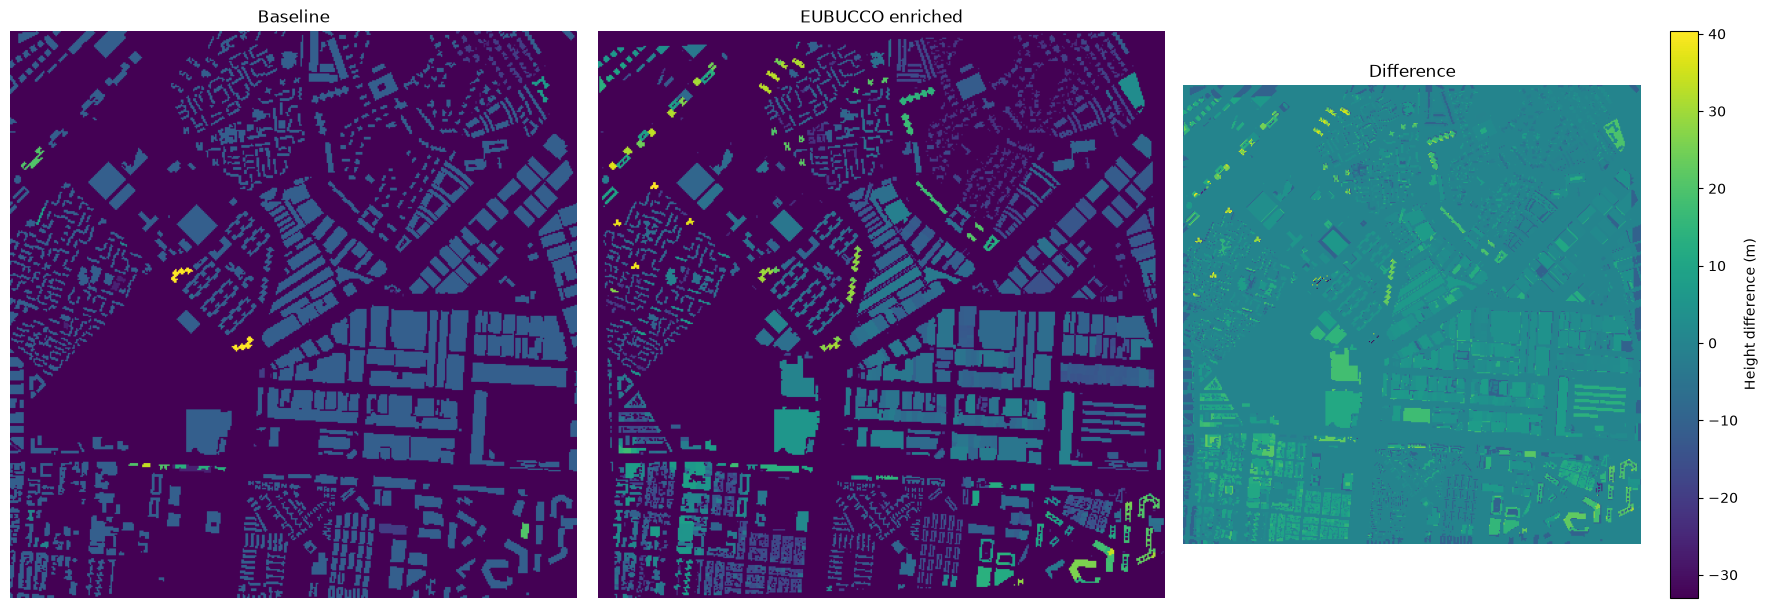

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(old, origin="lower")
axes[0].set_title("Baseline")

axes[1].imshow(new, origin="lower")
axes[1].set_title("EUBUCCO enriched")

im = axes[2].imshow(diff, origin="lower")
axes[2].set_title("Difference")

for ax in axes:
    ax.set_axis_off()

plt.colorbar(im, ax=axes[2], label="Height difference (m)")
plt.tight_layout()
plt.show()

In [28]:
from voxcity.generator import save_voxcity

save_voxcity(
    DATA_INTERIM / "sevilla_voxcity_eubucco.pkl",
    voxcity_eubucco
)

INFO | voxcity.voxcity.io | Voxcity data saved to /Users/modjrin1/Library/CloudStorage/OneDrive-AaltoUniversity/paper 4 - mobility spain/heat-conditioned-accessibility/data/interim/sevilla_voxcity_eubucco.pkl


In [29]:
import json

ds_enriched = voxcity_eubucco.to_xarray()

ds_enriched_nc = ds_enriched.copy()

ds_enriched_nc.attrs["rectangle_vertices"] = json.dumps(
    ds_enriched.attrs["rectangle_vertices"].tolist()
)

ds_enriched_nc.to_netcdf(
    DATA_INTERIM / "sevilla_voxcity_eubucco.nc"
)